In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"D:\Downloads\house-prices-advanced-regression-techniques\train.csv")

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

<Axes: >

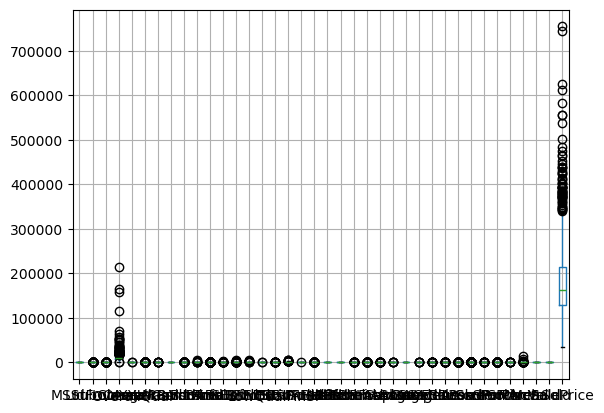

In [6]:
df.boxplot()

In [7]:
df.shape

(1460, 81)

In [8]:
# Drop columns with too many missing values (e.g. > 50%)
missing_ratio = df.isnull().mean()
drop_cols = missing_ratio[missing_ratio > 0.5].index.tolist()
df = df.drop(columns=drop_cols)
print("Dropped columns due to missing values:", drop_cols)


Dropped columns due to missing values: ['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature']


In [9]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 76, dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [11]:
# 1. Fill 'None' in categorical columns where NA means "no such feature"
none_cols = ['Alley', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
             'GarageCond', 'PoolQC', 'Fence', 'MiscFeature', 'BsmtQual',
             'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']
for col in none_cols:
    if col in df.columns:
        df[col] = df[col].fillna('None')

# 2. Fill 0 where NA means "feature not present"
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
             'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in zero_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# 3. Fill mode for normal categorical missingness
mode_cols = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st',
             'Exterior2nd', 'SaleType', 'Functional']
for col in mode_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

# 4. LotFrontage -> fill using Neighborhood median
if 'LotFrontage' in df.columns and 'Neighborhood' in df.columns:
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )

# ✅ Final Check
print("Missing values left:", df.isnull().sum().sum())


Missing values left: 0


In [12]:
df.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 76, dtype: int64

In [13]:
import seaborn as sns 
import matplotlib.pyplot as plt

In [21]:
# ✅ 1. Total Square Footage
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# ✅ 2. Total Bathrooms (with 0.5 weight for half baths)
df['TotalBath'] = (df['FullBath'] + 0.5 * df['HalfBath'] +
                   df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])

# ✅ 3. Age of the house
df['Age'] = df['YrSold'] - df['YearBuilt']

# ✅ 4. Age since remodel
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

# ✅ 5. IsRemodeled (binary feature)
df['IsRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)

# ✅ 6. TotalPorchSF (sum of all porch areas)
df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] +
                      df['3SsnPorch'] + df['ScreenPorch'])

# ✅ 7. HasPool, HasFireplace, HasGarage (binary)
df['HasPool'] = (df['PoolArea'] > 0).astype(int)
df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)


KeyError: 'TotalBsmtSF'

In [20]:
df.drop(columns=[
    'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
    'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath',
    'YearBuilt', 'YearRemodAdd',
    'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
    'PoolArea', 'Fireplaces', 'GarageArea'
], inplace=True, errors='ignore')


In [16]:
df.shape

(1460, 69)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 69 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  RoofStyl

In [23]:
obj_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Total object columns: {len(obj_cols)}")
print(obj_cols)


Total object columns: 38
['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 69 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  RoofStyl

In [25]:
df = pd.get_dummies(df, columns=[col for col in obj_cols if df[col].nunique() > 2], drop_first=True)


In [26]:
for col in obj_cols:
    df[col] = df[col].astype('category')


KeyError: 'MSZoning'

In [27]:
print(df.dtypes.value_counts())


bool       204
int64       23
float64      4
int32        4
object       3
Name: count, dtype: int64


In [28]:
for col in obj_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')


In [29]:
existing_obj_cols = [col for col in obj_cols if col in df.columns]
df[existing_obj_cols] = df[existing_obj_cols].astype('category')


In [30]:
print(df.dtypes.value_counts())

bool        204
int64        23
float64       4
int32         4
category      1
category      1
category      1
Name: count, dtype: int64


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 238 entries, Id to SaleCondition_Partial
dtypes: bool(204), category(3), float64(4), int32(4), int64(23)
memory usage: 626.4 KB


In [34]:
df.head()

,Id,MSSubClass,LotFrontage,LotArea,Street,Utilities,OverallQual,OverallCond,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,Pave,AllPub,7,5,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,Pave,AllPub,6,8,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,Pave,AllPub,7,5,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,Pave,AllPub,7,5,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,Pave,AllPub,8,5,350.0,655,...,False,False,False,False,True,False,False,False,True,False


In [35]:
# Encode binary object columns (e.g., 'Yes'/'No', 'True'/'False')
binary_map = {'Yes': 1, 'No': 0, 'True': 1, 'False': 0, 'Y': 1, 'N': 0}
for col in df.select_dtypes(include='object').columns:
    unique_vals = df[col].dropna().unique().tolist()
    if set(unique_vals).issubset(set(binary_map.keys())):
        df[col] = df[col].map(binary_map)

# Encode boolean columns
df[df.select_dtypes(include='bool').columns] = df.select_dtypes(include='bool').astype(int)


In [36]:
df.head()

,Id,MSSubClass,LotFrontage,LotArea,Street,Utilities,OverallQual,OverallCond,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,Pave,AllPub,7,5,196.0,706,...,0,0,0,0,1,0,0,0,1,0
1,2,20,80.0,9600,Pave,AllPub,6,8,0.0,978,...,0,0,0,0,1,0,0,0,1,0
2,3,60,68.0,11250,Pave,AllPub,7,5,162.0,486,...,0,0,0,0,1,0,0,0,1,0
3,4,70,60.0,9550,Pave,AllPub,7,5,0.0,216,...,0,0,0,0,1,0,0,0,0,0
4,5,60,84.0,14260,Pave,AllPub,8,5,350.0,655,...,0,0,0,0,1,0,0,0,1,0


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 238 entries, Id to SaleCondition_Partial
dtypes: category(3), float64(4), int32(208), int64(23)
memory usage: 1.5 MB


In [38]:
df['Street'] = df['Street'].map({'Pave': 1, 'Gravel': 0})
df['Utilities'] = df['Utilities'].map({'AllPub': 1, 'NoSeWa': 0})


In [40]:
for col in df.select_dtypes(include='object').columns:
    if df[col].nunique() == 1:
        print(f"Dropping low-variance column: {col}")
        df.drop(columns=[col], inplace=True)


In [41]:
print(df.select_dtypes(include='object').columns)


Index([], dtype='object')


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 238 entries, Id to SaleCondition_Partial
dtypes: category(2), float64(5), int32(208), int64(23)
memory usage: 1.5 MB


In [43]:
df.head()

,Id,MSSubClass,LotFrontage,LotArea,Street,Utilities,OverallQual,OverallCond,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,1.0,1,7,5,196.0,706,...,0,0,0,0,1,0,0,0,1,0
1,2,20,80.0,9600,1.0,1,6,8,0.0,978,...,0,0,0,0,1,0,0,0,1,0
2,3,60,68.0,11250,1.0,1,7,5,162.0,486,...,0,0,0,0,1,0,0,0,1,0
3,4,70,60.0,9550,1.0,1,7,5,0.0,216,...,0,0,0,0,1,0,0,0,0,0
4,5,60,84.0,14260,1.0,1,8,5,350.0,655,...,0,0,0,0,1,0,0,0,1,0


In [47]:
df.dtypes

Id                         int64
MSSubClass                 int64
LotFrontage              float64
LotArea                    int64
Street                   float64
                          ...   
SaleCondition_AdjLand      int32
SaleCondition_Alloca       int32
SaleCondition_Family       int32
SaleCondition_Normal       int32
SaleCondition_Partial      int32
Length: 238, dtype: object

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 238 entries, Id to SaleCondition_Partial
dtypes: category(2), float64(5), int32(208), int64(23)
memory usage: 1.5 MB


In [49]:
df.shape

(1460, 238)

In [50]:
df.dtypes.value_counts()


int32       208
int64        23
float64       5
category      1
category      1
Name: count, dtype: int64

In [51]:
df.select_dtypes(include='category').columns

Index(['Utilities', 'CentralAir'], dtype='object')

In [52]:
print(df['Utilities'].unique())
print(df['CentralAir'].unique())

[1, 0]
Categories (2, int64): [1, 0]
['Y', 'N']
Categories (2, object): ['N', 'Y']


In [53]:
df.drop(columns=['Utilities'], inplace=True)


In [54]:
df['CentralAir'] = (df['CentralAir'] == 'Y').astype(int)


In [55]:
df.dtypes.value_counts()

int32      209
int64       23
float64      5
Name: count, dtype: int64

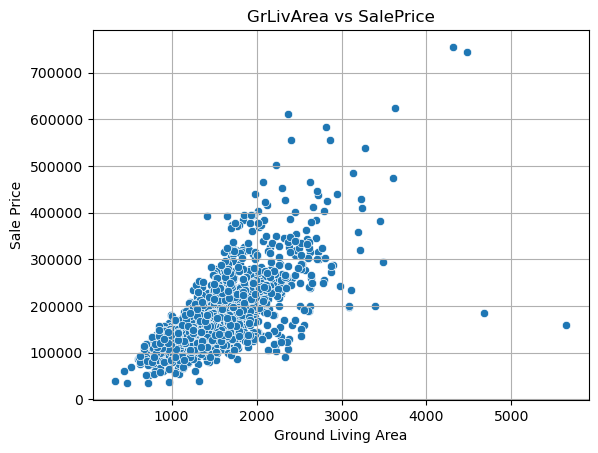

In [57]:
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title('GrLivArea vs SalePrice')
plt.xlabel('Ground Living Area')
plt.ylabel('Sale Price')
plt.grid(True)
plt.show()


In [58]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]
df = remove_outliers(df, 'GrLivArea')


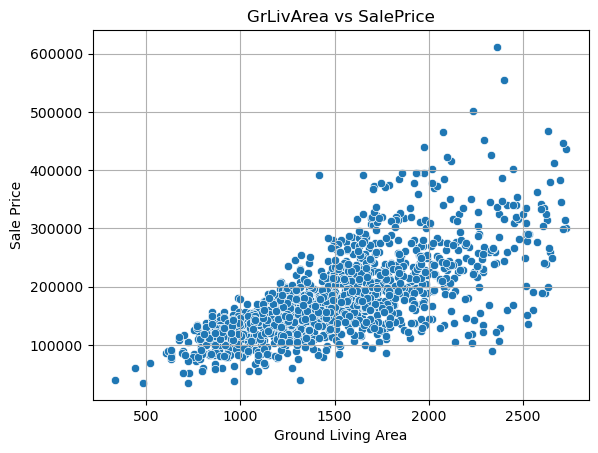

In [59]:
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title('GrLivArea vs SalePrice')
plt.xlabel('Ground Living Area')
plt.ylabel('Sale Price')
plt.grid(True)
plt.show()


In [60]:
from sklearn.linear_model import LinearRegression

In [80]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

In [81]:
from sklearn.model_selection import train_test_split
X_train,y_train,X_test,y_test = train_test_split(X,y,test_size=0.2,random_state=45)

In [82]:
lr = LinearRegression()
lr.fit(X_train,y_train)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [66]:
X.isnull().sum()

Id                       0
MSSubClass               0
LotFrontage              0
LotArea                  0
Street                   6
                        ..
SaleCondition_AdjLand    0
SaleCondition_Alloca     0
SaleCondition_Family     0
SaleCondition_Normal     0
SaleCondition_Partial    0
Length: 236, dtype: int64

In [78]:
from sklearn.impute import SimpleImputer
import pandas as pd

# 1. Numeric columns ke liye mean fill
num_cols = X.select_dtypes(include=['int64', 'int32', 'float64']).columns
imputer_num = SimpleImputer(strategy='mean')
X[num_cols] = pd.DataFrame(imputer_num.fit_transform(X[num_cols]), columns=num_cols, index=X.index)

# 2. Categorical columns (in case any still exist, just for safety)
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns
if len(cat_cols) > 0:
    imputer_cat = SimpleImputer(strategy='most_frequent')
    X[cat_cols] = pd.DataFrame(imputer_cat.fit_transform(X[cat_cols]), columns=cat_cols, index=X.index)

# ✅ Final Check
print("Still Missing:\n", X.isnull().sum()[X.isnull().sum() > 0])


Still Missing:
 Series([], dtype: int64)


In [79]:
X.isnull().sum()

Id                       0
MSSubClass               0
LotFrontage              0
LotArea                  0
Street                   0
                        ..
SaleCondition_AdjLand    0
SaleCondition_Alloca     0
SaleCondition_Family     0
SaleCondition_Normal     0
SaleCondition_Partial    0
Length: 236, dtype: int64

In [83]:
print('Street' in X.columns)


True


In [84]:
X.drop(columns=['Street'], inplace=True)

In [85]:
lr = LinearRegression()
lr.fit(X_train,y_train)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [86]:
nan_cols = X.columns[X.isnull().any()]
print("NaN Columns:\n", X[nan_cols].isnull().sum())



NaN Columns:
 Series([], dtype: float64)


In [87]:
print("\nDtypes of NaN Columns:\n", X[nan_cols].dtypes)



Dtypes of NaN Columns:
 Series([], dtype: object)


In [88]:
from sklearn.impute import SimpleImputer
import pandas as pd

# All NaN columns — regardless of dtype — fill with strategy that makes sense

for col in nan_cols:
    if X[col].dtype in ['float64', 'int64']:
        # Numeric column — use mean
        imputer = SimpleImputer(strategy='mean')
    else:
        # Categorical column — use most frequent
        imputer = SimpleImputer(strategy='most_frequent')
    
    # Fit & transform
    X[[col]] = imputer.fit_transform(X[[col]])


In [89]:
print("✅ Final Missing Values:\n", X.isnull().sum().sum())  # Should be 0


✅ Final Missing Values:
 0


In [91]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Step 1: Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Define the model
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    tree_method="hist",  # fast and efficient
    enable_categorical=True  # if you still have any categorical types
)

# Step 3: Fit the model
xgb.fit(X_train, y_train)

# Step 4: Predict
y_pred = xgb.predict(X_test)

# Step 5: Evaluate
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"✅ RMSE: {rmse:.4f}")


✅ RMSE: 21969.3910


C:\Users\sumit\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [92]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(f"✅ R² Score: {r2:.4f}")


✅ R² Score: 0.8985


In [93]:
missing_cols = X.columns[X.isnull().any()]
print("Columns with missing values:\n", missing_cols)
print("\nMissing count:\n", X[missing_cols].isnull().sum())


Columns with missing values:
 Index([], dtype='object')

Missing count:
 Series([], dtype: float64)


In [94]:
missing_ratio = X.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > 0.3].index
X.drop(cols_to_drop, axis=1, inplace=True)


In [95]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import r2_score
print("R² Score:", r2_score(y_test, y_pred))


R² Score: 0.9103462823676445


In [101]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

# Load train & test
train_df = pd.read_csv(r"D:\Downloads\house-prices-advanced-regression-techniques\train.csv")
test_df = pd.read_csv(r"D:\Downloads\house-prices-advanced-regression-techniques\test.csv")

# Split train into X and y
X = train_df.drop(columns=["SalePrice"])
y = train_df["SalePrice"]

# Combine for consistent preprocessing
all_data = pd.concat([X, test_df], keys=["train", "test"])


In [102]:
# Drop 'Id' if not useful
all_data = all_data.drop(columns=["Id"])

# Fill numeric columns with mean
num_cols = all_data.select_dtypes(include=['int64', 'float64']).columns
imputer_num = SimpleImputer(strategy='mean')
all_data[num_cols] = imputer_num.fit_transform(all_data[num_cols])

# Fill categorical with mode
cat_cols = all_data.select_dtypes(include=['object']).columns
imputer_cat = SimpleImputer(strategy='most_frequent')
all_data[cat_cols] = imputer_cat.fit_transform(all_data[cat_cols])

# One-hot encode
all_data = pd.get_dummies(all_data)

# Split back to train and test
X_processed = all_data.loc["train"]
test_processed = all_data.loc["test"]

# Align columns (in case test has extra/missing dummies)
X_processed, test_processed = X_processed.align(test_processed, join="left", axis=1, fill_value=0)


In [103]:
# Train Linear Regression
model = LinearRegression()
model.fit(X_processed, y)

# Predict on test
y_pred_test = model.predict(test_processed)


In [104]:
submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": y_pred_test
})
submission.to_csv("submission2.csv", index=False)
print("✅ Done! submission.csv saved.")


✅ Done! submission.csv saved.


In [106]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load data
train_df = pd.read_csv(r"D:\Downloads\house-prices-advanced-regression-techniques\train.csv")
test_df = pd.read_csv(r"D:\Downloads\house-prices-advanced-regression-techniques\test.csv")

# Split train data
X = train_df.drop("SalePrice", axis=1)
y = train_df["SalePrice"]

# Combine for preprocessing
combined = pd.concat([X, test_df], axis=0)

# Identify column types
cat_cols = combined.select_dtypes(include="object").columns
num_cols = combined.select_dtypes(include=["int64", "float64"]).columns.drop("Id")

# Pipelines
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean"))
])
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# Final model pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Fit and predict
model.fit(X, y)
preds = model.predict(test_df)

# Save predictions
submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": preds
})
submission.to_csv("house_submission_final.csv", index=False)
print("✅ Submission file created: house_submission_final.csv")


✅ Submission file created: house_submission_final.csv


In [ ]:
import pandas as pd

train_df = pd.read_csv("train.csv")
print(train_df.columns)
